## Introduction

Federated Learning (FL) enables multiple clients to collaboratively train a machine learning model without sharing their raw data. Instead, each client performs local training and only model updates are exchanged with a central server.

### Objectives

* Simulate a federated learning environment using the CIFAR-10 dataset.
* Evaluate model performance under an IID (Independent and Identically Distributed) data setting.
* Compare different aggregation methods used in federated learning.
* Investigate the effect of adaptive gradient clipping on training stability.

### Aggregation Methods Compared

* FedAvg
* FedAvg + Gradient Clipping
* FedProx + Gradient Clipping
* Trimmed Mean + Gradient Clipping
* SCAFFOLD + Gradient Clipping

### Experimental Setup

* Dataset: CIFAR-10
* Data Distribution: IID
* Model: Convolutional Neural Network (CNN)
* Evaluation Metrics:

  * Test Accuracy
  * Training Loss

### Adaptive Gradient Clipping

Instead of selecting a fixed clipping threshold, gradient norms were collected during a short calibration run. The clipping threshold was then chosen as the 95th percentile of the observed gradient norm distribution. This data-driven approach clips only extreme gradients while preserving the majority of normal updates.


In [1]:
!pip install torch torchvision -q

## Verify GPU

In [2]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## Import Libraries

In [4]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import time
import os

## Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
project_path = "/content/drive/MyDrive/FL_Project"

os.makedirs(project_path, exist_ok=True)

dataset_path = os.path.join(project_path, "datasets")

os.makedirs(dataset_path, exist_ok=True)

## Download CIFAR-10 Dataset

(Note that we have not used data augmentation (padding and horizontal flip))

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root=dataset_path,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=dataset_path,
    train=False,
    download=True,
    transform=transform
)

## Create Test Loader

In [8]:
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    drop_last=True,
    pin_memory=torch.cuda.is_available()
)

## Create IID Client Dataset:

In [9]:
num_clients = 10

indices = np.random.permutation(len(train_dataset))

split_indices = np.array_split(indices, num_clients)

client_loaders = []

for idx in split_indices:

    subset = Subset(train_dataset, idx)

    loader = DataLoader(
        subset,
        batch_size=64,
        shuffle=True,
        drop_last=True,
         pin_memory=torch.cuda.is_available()
    )

    client_loaders.append(loader)

print("Created IID client datasets!")

Created IID client datasets!


## Verify Client Data Sizes

In [10]:
for i, loader in enumerate(client_loaders):
    print(f"Client {i}: {len(loader.dataset)} samples")

Client 0: 5000 samples
Client 1: 5000 samples
Client 2: 5000 samples
Client 3: 5000 samples
Client 4: 5000 samples
Client 5: 5000 samples
Client 6: 5000 samples
Client 7: 5000 samples
Client 8: 5000 samples
Client 9: 5000 samples


## Define CNN Model

In [11]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

## Hyperparameters


In [12]:
# =========================================================
# TRAINING CONFIGURATION
# =========================================================

ROUNDS = 15
CLIENTS_PER_ROUND = 4
LOCAL_EPOCHS = 1
MU= 0.01

## Gradient Clipping

Gradient clipping is used to prevent excessively large gradients during local client training. Instead of using a fixed clipping threshold, a data-driven approach was adopted.

A short calibration run was performed to collect gradient norms from all participating clients. The 95th percentile of the collected gradient norm distribution was then selected as the clipping threshold.

This approach ensures that approximately 95% of normal gradient updates remain unaffected, while only the largest 5% of gradients are clipped. The resulting threshold was subsequently used for all federated learning experiments to improve training stability and maintain a fair comparison across aggregation methods.

## Gradient Norm Tracking


In [13]:


gradient_norms = []

def get_gradient_norm(model):

    total_norm = 0.0

    for p in model.parameters():

        if p.grad is not None:

            param_norm = p.grad.data.norm(2)

            total_norm += param_norm.item() ** 2

    return total_norm ** 0.5

## Scaffold control variates

In [14]:
# =========================================================
# SCAFFOLD CONTROL VARIATES
# =========================================================

server_control = {}

temp_model = CNN().to(device)

for key, value in temp_model.named_parameters():

    server_control[key] = torch.zeros_like(value)

client_controls = []

for _ in range(num_clients):

    local_control = {}

    for key, value in temp_model.named_parameters():

        local_control[key] = torch.zeros_like(value)

    client_controls.append(local_control)

print("SCAFFOLD control variates initialized!")

SCAFFOLD control variates initialized!


## Define Global Model

In [15]:
global_model = CNN().to(device)

print(global_model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


## Define Evaluation Function

In [16]:
def evaluate(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

## Define Local Training Function (with Gradient Clipping)

In [17]:
def local_train(
    model,
    global_model,
    loader,
    epochs=1,
    lr=0.01,
    clip_grad=True,
    max_norm=1.0,
    fedprox=False,
    mu=0.01
):

    model.train()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    epoch_loss = 0

    global_weights = copy.deepcopy(global_model.state_dict())

    for epoch in range(epochs):

        batch_losses = []

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            # =================================================
            # FEDPROX PROXIMAL TERM
            # =================================================

            if fedprox:

                proximal_term = 0.0

                for param, global_param in zip(
                    model.parameters(),
                    global_model.parameters()
                ):

                    proximal_term += torch.norm(
                        param - global_param
                    ) ** 2

                loss += (mu / 2) * proximal_term

            # =================================================
            # BACKPROPAGATION
            # =================================================

            loss.backward()

            grad_norm = get_gradient_norm(model)

            gradient_norms.append(grad_norm)

            # =================================================
            # GRADIENT CLIPPING
            # =================================================

            if clip_grad:

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_norm
                )

            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss += sum(batch_losses) / len(batch_losses)

    avg_loss = epoch_loss / epochs

    return model.state_dict(), avg_loss

# =========================================================
# 11. FEDAVG AGGREGATION
# =========================================================

def fedavg_aggregate(global_model, client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], 0).mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

In [18]:
# =========================================================
# SCAFFOLD LOCAL TRAINING
# =========================================================

def scaffold_local_train(
    model,
    global_model,
    loader,
    client_control,
    server_control,
    epochs=1,
    lr=0.001,
    clip_grad=True,
    max_norm=1.0
):

    model.train()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    epoch_loss = 0

    # Store initial global weights
    global_weights = {
        name: param.data.clone()
        for name, param in global_model.named_parameters()
    }

    for epoch in range(epochs):

        batch_losses = []

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            # =================================================
            # SCAFFOLD CORRECTION
            # =================================================

            with torch.no_grad():

                for name, param in model.named_parameters():

                    correction = (
                        server_control[name]
                        - client_control[name]
                    )

                    param.grad -= correction.to(device)

            # =================================================
            # GRADIENT CLIPPING
            # =================================================

            if clip_grad:

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_norm
                )

            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss += sum(batch_losses) / len(batch_losses)

    avg_loss = epoch_loss / epochs

    # =====================================================
    # UPDATE CLIENT CONTROL VARIATE
    # =====================================================

    new_client_control = {}

    local_weights = {
    name: param.data.clone()
    for name, param in model.named_parameters()
    }

    for key in client_control.keys():

        new_client_control[key] = (
        client_control[key]
        + 0.1 * (
            global_weights[key] - local_weights[key]
        )
    )

    return (
        model.state_dict(),
        avg_loss,
        new_client_control
    )

## Define FedAvg Aggregation

In [19]:
def fedavg_aggregate(global_model, client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], 0).mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

## 12. TRIMMED MEAN AGGREGATION (5%):

In [20]:
def trimmed_mean_aggregate(
    global_model,
    client_weights,
    trim_ratio=0.05
):

    global_dict = global_model.state_dict()

    num_clients = len(client_weights)

    trim_k = max(1, int(num_clients * trim_ratio))

    for key in global_dict.keys():

        stacked = torch.stack([
            client_weights[i][key].float()
            for i in range(num_clients)
        ], 0)

        sorted_vals, _ = torch.sort(stacked, dim=0)

        trimmed = sorted_vals[
            trim_k : num_clients - trim_k
        ]

        global_dict[key] = trimmed.mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

## Generic Federated Training Loop

In [21]:
def federated_train(
    method_name="FedAvg",
    rounds=2,
    clients_per_round=2,
    local_epochs=1,
    clip_grad=True,
    fedprox=False,
    trimmed_mean=False,
    scaffold=False,
    max_norm=1.0
):

    print("\n" + "="*70)
    print(f"METHOD: {method_name}")
    print("="*70)

    global_model = CNN().to(device)

    global_accuracies = []

    round_losses = []

    best_accuracy = 0

    best_model_weights = None

    previous_accuracy = 0

    for round_num in range(rounds):

        start_time = time.time()

        print("\n" + "="*60)
        print(f"Round {round_num+1}/{rounds}")
        print("="*60)

        # =================================================
        # CLIENT SELECTION
        # =================================================

        selected_clients = np.random.choice(
            range(num_clients),
            clients_per_round,
            replace=False
        )

        print(f"\nSelected Clients: {selected_clients}\n")

        client_weights = []

        client_losses = []

        # =================================================
        # LOCAL TRAINING
        # =================================================

        for client_id in selected_clients:

          local_model = copy.deepcopy(global_model)

          # =====================================================
          # SCAFFOLD TRAINING
          # =====================================================

          if scaffold:

              weights, loss, updated_control = scaffold_local_train(
                  model=local_model,
                  global_model=global_model,
                  loader=client_loaders[client_id],
                  client_control=client_controls[client_id],
                  server_control=server_control,
                  epochs=local_epochs,
                  clip_grad=clip_grad,
                  max_norm=max_norm
              )

              client_controls[client_id] = updated_control

          # =====================================================
          # NORMAL METHODS
          # =====================================================

          else:

              weights, loss = local_train(
                  model=local_model,
                  global_model=global_model,
                  loader=client_loaders[client_id],
                  epochs=local_epochs,
                  clip_grad=clip_grad,
                  fedprox=fedprox,
                  max_norm=max_norm
              )

          client_weights.append(weights)

          client_losses.append(loss)

          print(f"Client {client_id} Loss: {loss:.4f}")

        # =================================================
        # AGGREGATION
        # =================================================

        if trimmed_mean:

            global_model = trimmed_mean_aggregate(
                global_model,
                client_weights,
                trim_ratio=0.05
            )



        else:

            global_model = fedavg_aggregate(
                global_model,
                client_weights
            )


        # =================================================
        # EVALUATE GLOBAL MODEL
        # =================================================

        accuracy = evaluate(global_model, test_loader)

        global_accuracies.append(accuracy)

        avg_client_loss = sum(client_losses) / len(client_losses)

        round_losses.append(avg_client_loss)

        accuracy_change = accuracy - previous_accuracy

        if accuracy > best_accuracy:

            best_accuracy = accuracy

            best_model_weights = copy.deepcopy(
                global_model.state_dict()
            )

        round_duration = time.time() - start_time

        # =================================================
        # ROUND SUMMARY
        # =================================================

        print("\n" + "-"*20 + " ROUND SUMMARY " + "-"*20)

        print(f"\nAverage Client Loss : {avg_client_loss:.4f}")

        print(f"Global Accuracy     : {accuracy:.2f}%")

        print(f"Accuracy Change     : {accuracy_change:+.2f}%")

        print(f"Best Accuracy       : {best_accuracy:.2f}%")

        print(f"Round Duration      : {round_duration:.2f} sec")

        previous_accuracy = accuracy

    # =====================================================
    # LOAD BEST MODEL
    # =====================================================

    global_model.load_state_dict(best_model_weights)

    # =====================================================
    # SAVE MODEL
    # =====================================================

    save_path = os.path.join(
        project_path,
        f"{method_name}_best_model.pth"
    )

    torch.save(best_model_weights, save_path)

    print("\nTraining Complete!")

    print(f"Best Accuracy: {best_accuracy:.2f}%")

    return global_accuracies,  round_losses


## CALIBRATION RUN


In [22]:

gradient_norms = []

print("\nRunning Calibration...")

_ = federated_train(
    method_name="Calibration",
    rounds=3,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    clip_grad=True
)

import numpy as np

OPTIMAL_CLIP_NORM = np.percentile(
    gradient_norms,
    95
)

print(
    f"\nOptimal Clip Norm = "
    f"{OPTIMAL_CLIP_NORM:.4f}"
)


Running Calibration...

METHOD: Calibration

Round 1/3

Selected Clients: [3 8 7 6]

Client 3 Loss: 2.1770
Client 8 Loss: 2.1839
Client 7 Loss: 2.1873
Client 6 Loss: 2.1899

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.1845
Global Accuracy     : 29.46%
Accuracy Change     : +29.46%
Best Accuracy       : 29.46%
Round Duration      : 10.87 sec

Round 2/3

Selected Clients: [9 6 4 8]

Client 9 Loss: 1.9227
Client 6 Loss: 1.9270
Client 4 Loss: 1.9198
Client 8 Loss: 1.9302

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.9249
Global Accuracy     : 35.45%
Accuracy Change     : +5.99%
Best Accuracy       : 35.45%
Round Duration      : 8.31 sec

Round 3/3

Selected Clients: [5 6 3 8]

Client 5 Loss: 1.7789
Client 6 Loss: 1.7877
Client 3 Loss: 1.7696
Client 8 Loss: 1.7793

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.7789
Global Accuracy     : 40.68%
Accuracy Change     : +5.23%
Best Accura

## Plotting the justification

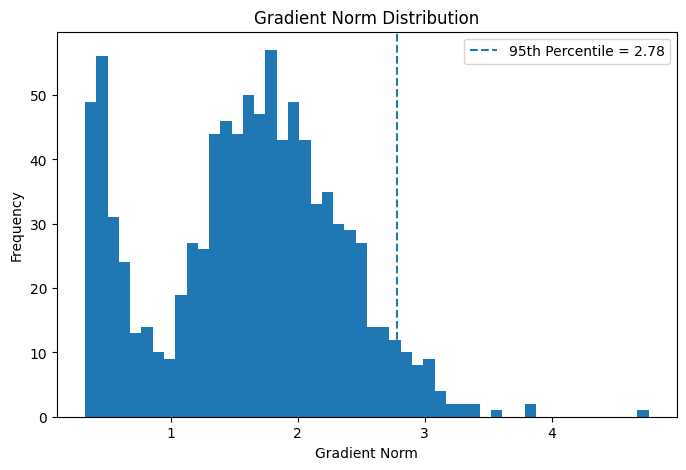

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    gradient_norms,
    bins=50
)

plt.axvline(
    OPTIMAL_CLIP_NORM,
    linestyle="--",
    label=f"95th Percentile = {OPTIMAL_CLIP_NORM:.2f}"
)

plt.xlabel("Gradient Norm")
plt.ylabel("Frequency")
plt.title("Gradient Norm Distribution")

plt.legend()

plt.show()

In [24]:
# =========================================================
# 14. RUN EXPERIMENTS
# =========================================================

# ---------------------------------------------------------
# 1. FEDAVG (NO CLIPPING)
# ---------------------------------------------------------

fedavg_acc, fedavg_loss = federated_train(
    method_name="FedAvg_NoClipping",
    clip_grad=False,
    fedprox=False,
    trimmed_mean=False,
    rounds=ROUNDS,
  clients_per_round=CLIENTS_PER_ROUND,
  local_epochs=LOCAL_EPOCHS,
     max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedAvg_NoClipping

Round 1/15

Selected Clients: [3 2 4 8]

Client 3 Loss: 2.1894
Client 2 Loss: 2.1990
Client 4 Loss: 2.1873
Client 8 Loss: 2.1972

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.1932
Global Accuracy     : 28.23%
Accuracy Change     : +28.23%
Best Accuracy       : 28.23%
Round Duration      : 9.36 sec

Round 2/15

Selected Clients: [4 3 6 5]

Client 4 Loss: 1.9060
Client 3 Loss: 1.9193
Client 6 Loss: 1.9274
Client 5 Loss: 1.9060

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.9147
Global Accuracy     : 39.23%
Accuracy Change     : +11.01%
Best Accuracy       : 39.23%
Round Duration      : 8.42 sec

Round 3/15

Selected Clients: [9 7 1 3]

Client 9 Loss: 1.6879
Client 7 Loss: 1.7300
Client 1 Loss: 1.7005
Client 3 Loss: 1.6939

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.7031
Global Accuracy     : 43.85%
Accuracy Change     : +4.62%
Best Accuracy       : 43.8

In [25]:
# ---------------------------------------------------------
# 2. FEDAVG + CLIPPING
# ---------------------------------------------------------

fedavg_clip_acc, fedavg_clip_loss = federated_train(
    method_name="FedAvg_Clipping",
    clip_grad=True,
    fedprox=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=False,
    max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedAvg_Clipping

Round 1/15

Selected Clients: [8 0 4 5]

Client 8 Loss: 2.1965
Client 0 Loss: 2.1952
Client 4 Loss: 2.1880
Client 5 Loss: 2.1953

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.1938
Global Accuracy     : 32.03%
Accuracy Change     : +32.03%
Best Accuracy       : 32.03%
Round Duration      : 8.10 sec

Round 2/15

Selected Clients: [0 4 1 5]

Client 0 Loss: 1.8948
Client 4 Loss: 1.8916
Client 1 Loss: 1.8879
Client 5 Loss: 1.8668

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.8853
Global Accuracy     : 39.40%
Accuracy Change     : +7.37%
Best Accuracy       : 39.40%
Round Duration      : 9.18 sec

Round 3/15

Selected Clients: [1 9 4 5]

Client 1 Loss: 1.6899
Client 9 Loss: 1.6844
Client 4 Loss: 1.6852
Client 5 Loss: 1.6895

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.6873
Global Accuracy     : 43.80%
Accuracy Change     : +4.40%
Best Accuracy       : 43.80%


In [26]:
# ---------------------------------------------------------
# 3. FEDPROX + CLIPPING
# ---------------------------------------------------------

fedprox_acc, fedprox_loss = federated_train(
    method_name="FedProx_Clipping",
    clip_grad=True,
    fedprox=True,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=False,
    max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedProx_Clipping

Round 1/15

Selected Clients: [6 7 2 4]

Client 6 Loss: 2.1875
Client 7 Loss: 2.1860
Client 2 Loss: 2.1903
Client 4 Loss: 2.1738

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.1844
Global Accuracy     : 28.87%
Accuracy Change     : +28.87%
Best Accuracy       : 28.87%
Round Duration      : 10.01 sec

Round 2/15

Selected Clients: [9 6 1 3]

Client 9 Loss: 1.9041
Client 6 Loss: 1.9224
Client 1 Loss: 1.9058
Client 3 Loss: 1.9030

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.9088
Global Accuracy     : 38.98%
Accuracy Change     : +10.12%
Best Accuracy       : 38.98%
Round Duration      : 9.53 sec

Round 3/15

Selected Clients: [5 4 9 0]

Client 5 Loss: 1.7077
Client 4 Loss: 1.7106
Client 9 Loss: 1.6957
Client 0 Loss: 1.7012

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.7038
Global Accuracy     : 44.62%
Accuracy Change     : +5.64%
Best Accuracy       : 44.6

In [27]:
# ---------------------------------------------------------
# 4. TRIMMED MEAN + CLIPPING
# ---------------------------------------------------------

trimmed_acc, trimmed_loss = federated_train(
    method_name="TrimmedMean_Clipping",
    clip_grad=True,
    fedprox=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=True,
     max_norm=OPTIMAL_CLIP_NORM
)


METHOD: TrimmedMean_Clipping

Round 1/15

Selected Clients: [8 4 3 2]

Client 8 Loss: 2.1468
Client 4 Loss: 2.1392
Client 3 Loss: 2.1415
Client 2 Loss: 2.1561

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.1459
Global Accuracy     : 30.75%
Accuracy Change     : +30.75%
Best Accuracy       : 30.75%
Round Duration      : 8.80 sec

Round 2/15

Selected Clients: [4 2 6 3]

Client 4 Loss: 1.8647
Client 2 Loss: 1.8771
Client 6 Loss: 1.8859
Client 3 Loss: 1.8577

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.8713
Global Accuracy     : 38.04%
Accuracy Change     : +7.29%
Best Accuracy       : 38.04%
Round Duration      : 9.28 sec

Round 3/15

Selected Clients: [5 6 2 1]

Client 5 Loss: 1.6950
Client 6 Loss: 1.7129
Client 2 Loss: 1.7083
Client 1 Loss: 1.7207

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.7092
Global Accuracy     : 44.07%
Accuracy Change     : +6.03%
Best Accuracy       : 44

In [28]:
# ---------------------------------------------------------
# 5. SCAFFOLD + CLIPPING
# ---------------------------------------------------------

scaffold_acc, scaffold_loss = federated_train(
    method_name="SCAFFOLD_Clipping",
    clip_grad=True,
    fedprox=False,
    trimmed_mean=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    scaffold=True,
    max_norm=OPTIMAL_CLIP_NORM
)


METHOD: SCAFFOLD_Clipping

Round 1/15

Selected Clients: [8 9 2 4]

Client 8 Loss: 2.2954
Client 9 Loss: 2.2956
Client 2 Loss: 2.2954
Client 4 Loss: 2.2950

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.2953
Global Accuracy     : 12.13%
Accuracy Change     : +12.13%
Best Accuracy       : 12.13%
Round Duration      : 9.06 sec

Round 2/15

Selected Clients: [9 8 6 5]

Client 9 Loss: 2.2725
Client 8 Loss: 2.2728
Client 6 Loss: 2.2724
Client 5 Loss: 2.2726

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.2726
Global Accuracy     : 19.31%
Accuracy Change     : +7.18%
Best Accuracy       : 19.31%
Round Duration      : 8.36 sec

Round 3/15

Selected Clients: [8 9 6 3]

Client 8 Loss: 2.2322
Client 9 Loss: 2.2307
Client 6 Loss: 2.2314
Client 3 Loss: 2.2312

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.2314
Global Accuracy     : 23.49%
Accuracy Change     : +4.18%
Best Accuracy       : 23.49

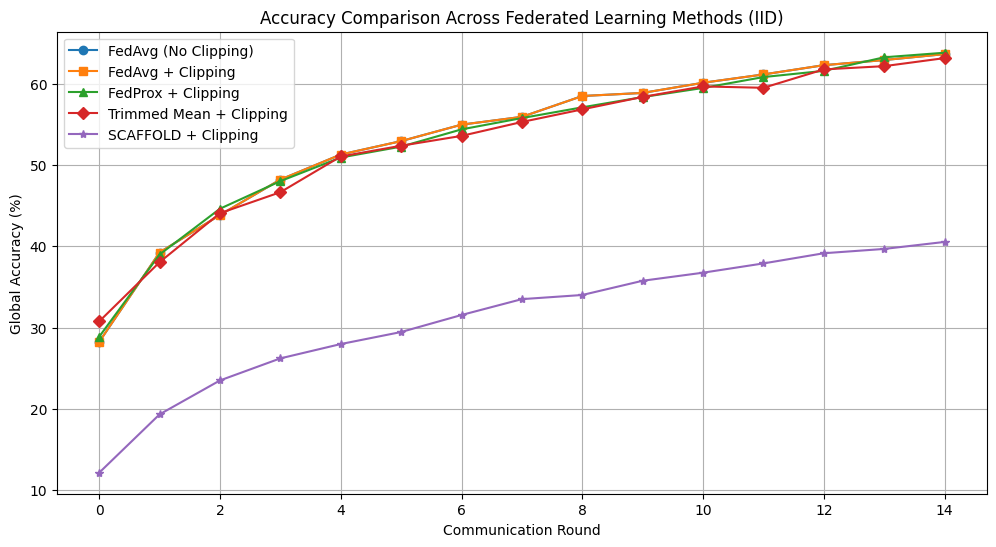

In [33]:
# =========================================================
# ACCURACY COMPARISON
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    fedavg_acc,
    marker='o',
    label="FedAvg (No Clipping)"
)

plt.plot(
    fedavg_acc,
    marker='s',
    label="FedAvg + Clipping"
)

plt.plot(
    fedprox_acc,
    marker='^',
    label="FedProx + Clipping"
)

plt.plot(
    trimmed_acc,
    marker='D',
    label="Trimmed Mean + Clipping"
)

plt.plot(
    scaffold_acc,
    marker='*',
    label="SCAFFOLD + Clipping"
)

plt.xlabel("Communication Round")
plt.ylabel("Global Accuracy (%)")
plt.title("Accuracy Comparison Across Federated Learning Methods (IID)")

plt.legend()
plt.grid(True)

plt.show()

In [30]:
# =========================================================
# 16. SAVE PLOT
# =========================================================

plot_path = os.path.join(
    project_path,
    "fl_comparison_plot.png"
)

plt.savefig(plot_path)

print("\nPlot Saved To:")
print(plot_path)


Plot Saved To:
/content/drive/MyDrive/FL_Project/fl_comparison_plot.png


<Figure size 640x480 with 0 Axes>

## Plot Losses

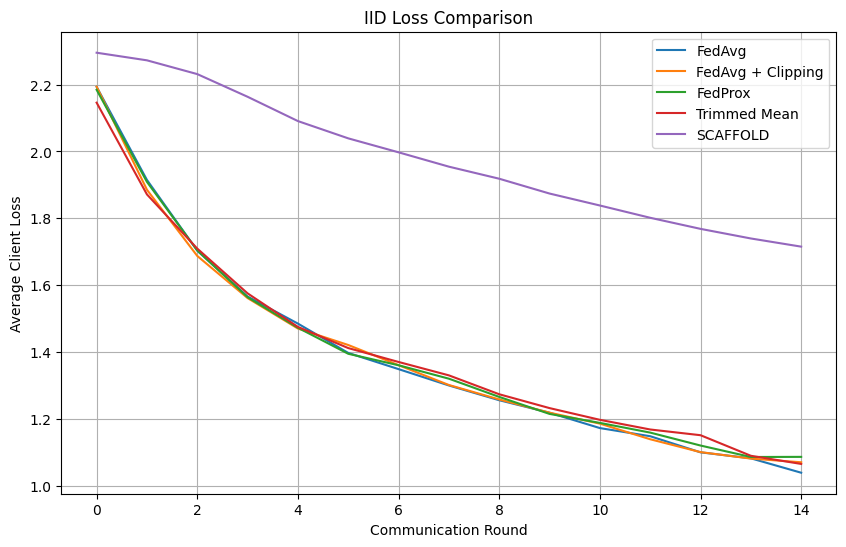

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(fedavg_loss, label="FedAvg")
plt.plot(fedavg_clip_loss, label="FedAvg + Clipping")
plt.plot(fedprox_loss, label="FedProx")
plt.plot(trimmed_loss, label="Trimmed Mean")
plt.plot(scaffold_loss, label="SCAFFOLD")

plt.xlabel("Communication Round")
plt.ylabel("Average Client Loss")
plt.title("IID Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [32]:
# =========================================================
# RESULTS COMPARISON TABLE
# =========================================================

import pandas as pd
import numpy as np

results_df = pd.DataFrame({

    "Method": [
        "FedAvg (No Clipping)",
        "FedAvg + Clipping",
        "FedProx + Clipping",
        "Trimmed Mean + Clipping",
        "SCAFFOLD + Clipping"
    ],

    "Best Accuracy (%)": [
        max(fedavg_acc),
        max(fedavg_clip_acc),
        max(fedprox_acc),
        max(trimmed_acc),
        max(scaffold_acc)
    ],

    "Final Accuracy (%)": [
        fedavg_acc[-1],
        fedavg_clip_acc[-1],
        fedprox_acc[-1],
        trimmed_acc[-1],
        scaffold_acc[-1]
    ],

    "Minimum Loss": [
        min(fedavg_loss),
        min(fedavg_clip_loss),
        min(fedprox_loss),
        min(trimmed_loss),
        min(scaffold_loss)
    ],

    "Final Loss": [
        fedavg_loss[-1],
        fedavg_clip_loss[-1],
        fedprox_loss[-1],
        trimmed_loss[-1],
        scaffold_loss[-1]
    ]

})

results_df = results_df.round(4)

results_df = results_df.sort_values(
    by="Best Accuracy (%)",
    ascending=False
)

display(results_df)

,Method,Best Accuracy (%),Final Accuracy (%),Minimum Loss,Final Loss
1,FedAvg + Clipping,64.2528,64.2528,1.0699,1.0699
2,FedProx + Clipping,63.8221,63.8221,1.0858,1.0861
0,FedAvg (No Clipping),63.6518,63.6518,1.0387,1.0387
3,Trimmed Mean + Clipping,63.1611,63.1611,1.0650,1.0650
4,SCAFFOLD + Clipping,40.5349,40.5349,1.7151,1.7151


## Conclusion

The IID experiments demonstrate that most aggregation methods achieved similar convergence behavior and final performance due to the homogeneous data distribution across clients. Since each client received a representative subset of the dataset, client drift was minimal, allowing standard federated averaging techniques to perform effectively.

### Key Findings

- **FedAvg + Gradient Clipping** achieved the highest accuracy (**64.25%**), indicating that adaptive gradient clipping helped stabilize local updates and slightly improved model performance.
- **FedProx + Gradient Clipping** achieved a comparable accuracy (**63.82%**), suggesting that proximal regularization provides limited additional benefit under IID conditions.
- **FedAvg (No Clipping)** achieved **63.65%** accuracy while producing the **lowest final loss (1.04)**, demonstrating strong baseline performance.
- **Trimmed Mean + Gradient Clipping** achieved **63.16%** accuracy, performing similarly to FedAvg but without any significant advantage in the absence of outlier client updates.
- **SCAFFOLD + Gradient Clipping** performed substantially worse, achieving only **40.53%** accuracy and the highest loss. This suggests that the control variate corrections introduced by SCAFFOLD may be unnecessary in IID settings and can slow convergence.

### Accuracy Analysis

The accuracy curves show that FedAvg, FedAvg + Clipping, FedProx, and Trimmed Mean followed nearly identical learning trajectories, steadily improving throughout training and converging above 60% accuracy. The differences between these methods remained relatively small, highlighting that sophisticated aggregation strategies offer limited benefits when client data distributions are homogeneous.

### Loss Analysis

The loss curves indicate consistent convergence for FedAvg, FedAvg + Clipping, FedProx, and Trimmed Mean, with all methods reaching similar final loss values. FedAvg achieved the lowest final loss, while FedAvg + Clipping achieved the highest final accuracy. In contrast, SCAFFOLD maintained significantly higher loss values throughout training, reflecting slower convergence and reduced learning efficiency.

### Overall Conclusion

For IID data, **FedAvg + Gradient Clipping emerged as the best-performing method**, achieving the highest classification accuracy while maintaining stable convergence. However, the performance gap among FedAvg, FedAvg + Clipping, FedProx, and Trimmed Mean was relatively small, indicating that simple aggregation methods are sufficient when client data distributions are similar. Advanced techniques such as FedProx and SCAFFOLD are expected to provide greater benefits in non-IID settings, where data heterogeneity and client drift become more prominent.